### Unsupervised Concept Discovery

---



In [79]:
# !pip install torch torchvision scikit-learn matplotlib
#!pip install Craft-xai
!pip install git+https://github.com/LAguirr/Craft.git
#!pip install git+https://github.com/lmb-freiburg/ucbm.git
#!pip install --force-reinstall git+https://github.com/LAguirr/Craft.git

  Cloning https://github.com/LAguirr/Craft.git to /tmp/pip-req-build-my7hmojb
  Running command git clone --filter=blob:none --quiet https://github.com/LAguirr/Craft.git /tmp/pip-req-build-my7hmojb
  Resolved https://github.com/LAguirr/Craft.git to commit 48b0a4bb16007b73dd5be52da833af17900a6a3c
  Preparing metadata (setup.py) ... done


In [80]:
!pip install grad-cam

In [81]:
!pip install opencv-python
!pip install torcheval

In [82]:
!pip install datautils

  Using cached datautils-1.0.3.tar.gz (25 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [83]:
### General libraries
import os
import numpy as np # linear algebra
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from sklearn.decomposition import NMF
from typing import List, Tuple, Dict, Any
from typing import Optional, Literal, Union, Callable

#Stuff
from sklearn.model_selection import train_test_split

#Datasets from Pytorch
from torchvision.datasets import MNIST
from torchvision.datasets import ImageFolder
import cv2
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#From ucbm file
from os import path, listdir, makedirs
from torch.utils.data import ConcatDataset, random_split, DataLoader, Subset, TensorDataset, Dataset, WeightedRandomSampler
from tqdm import tqdm, trange
import math
import tempfile
import shutil
from scipy.special import softmax
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from copy import deepcopy
from torcheval.metrics.functional import multilabel_accuracy, multiclass_accuracy, multiclass_auprc, multilabel_auprc, binary_auroc, multiclass_auroc, binary_auprc


import seaborn as sns
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

import random
import argparse
from datetime import datetime
import json


seed =0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


import warnings


In [84]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
num_workers = os.cpu_count()

# Filter out the specific UserWarning from PyTorch
warnings.filterwarnings("ignore", category=UserWarning, message=".*To copy construct from a tensor.*|.*This DataLoader will create.*")

cpu


Dataset MNIST
    Number of datapoints: 60000
    Root location: /content
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: /content
    Split: Test
    StandardTransform
Transform: ToTensor()
Percentage training:  0.8571428571428571
Percentage test:  0.14285714285714285
Labels shape:  (70000,)
[6903 7877 6990 7141 6824 6313 6876 7293 6825 6958]


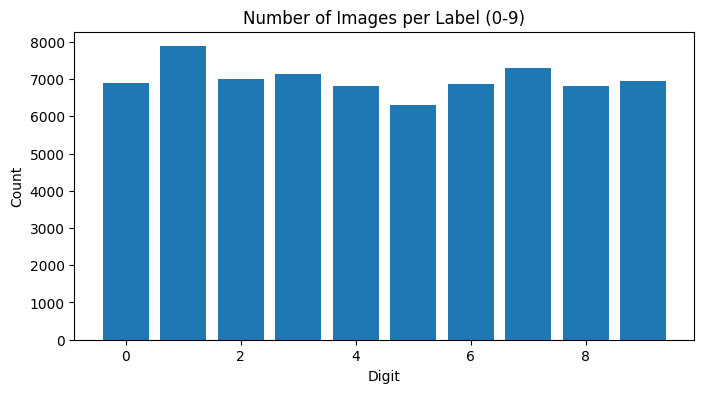

In [85]:
transform = transforms.ToTensor()
root = os.getcwd()
dataset_train = MNIST(root=root, download=True, train=True, transform=transform)
dataset_test = MNIST(root=root, download=True, train=False, transform=transform)
print(dataset_train)
print(dataset_test)

# Get labels as numpy array for stratification
labels_train = dataset_train.targets.numpy()
labels_test = dataset_test.targets.numpy()

labels = np.concatenate([labels_train,labels_test])
print("Percentage training: ", len(labels_train)/len(labels))
print("Percentage test: ", len(labels_test)/len(labels))

full_dataset = ConcatDataset([dataset_train, dataset_test])
print("Labels shape: ",labels.shape)
counts = np.bincount(labels, minlength=10)
print(counts)

plt.figure(figsize=(8, 4))
plt.bar(range(10), counts)
plt.title("Number of Images per Label (0-9)")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

Train length:  56000
Train labels:  [5522 6302 5592 5713 5459 5050 5501 5834 5460 5567]
Validation length:  7000
Validation labels:  [691 788 699 714 682 631 687 730 682 696]
Test length:  7000
Test labels:  [690 787 699 714 683 632 688 729 683 695]


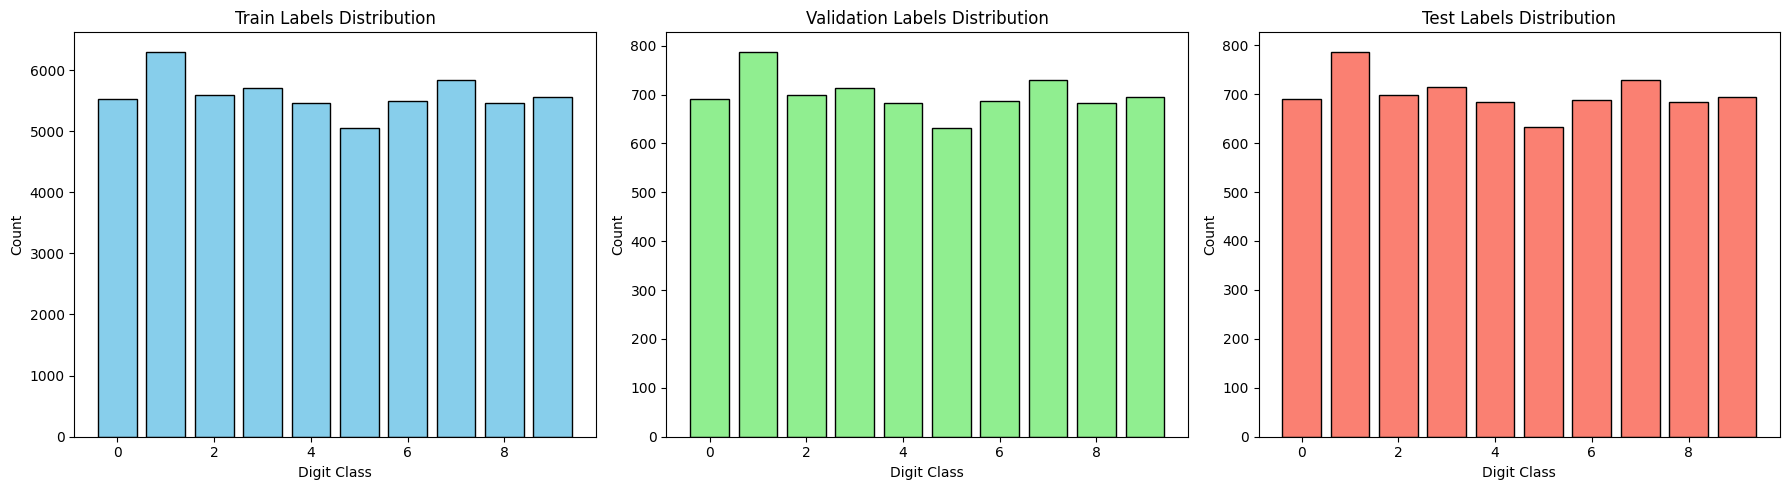

In [86]:
train_idx, temp_idx, _, temp_labels = train_test_split(
    range(len(full_dataset)), labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)
train_labels = np.bincount(_, minlength=10)


val_idx, test_idx, val_labels, test_labels = train_test_split(
    temp_idx, temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

val_labels = np.bincount(val_labels, minlength=10)
test_labels = np.bincount(test_labels, minlength=10)

print("Train length: ", len(train_idx))
print("Train labels: ", train_labels)

print("Validation length: ", len(val_idx))
print("Validation labels: ", val_labels)

print("Test length: ", len(test_idx))
print("Test labels: ", test_labels)



fig, axs = plt.subplots(1, 3, figsize=(18, 5))
classes = [0,1,2,3,4,5,6,7,8,9]

# Plot 1: Train Labels
axs[0].bar(classes, train_labels, color='skyblue', edgecolor='black')
axs[0].set_title('Train Labels Distribution')
axs[0].set_xlabel('Digit Class')
axs[0].set_ylabel('Count')

# Plot 2: Validation Labels
axs[1].bar(classes, val_labels, color='lightgreen', edgecolor='black')
axs[1].set_title('Validation Labels Distribution')
axs[1].set_xlabel('Digit Class')
axs[1].set_ylabel('Count')

# Plot 3: Test Labels
axs[2].bar(classes, test_labels, color='salmon', edgecolor='black')
axs[2].set_title('Test Labels Distribution')
axs[2].set_xlabel('Digit Class')
axs[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

train_ds = Subset(full_dataset, train_idx)
val_ds   = Subset(full_dataset, val_idx)
test_ds  = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

tensor([5, 0, 0, 3, 6, 6, 2, 1, 7, 3, 9, 9, 6, 4, 9, 3, 0, 9, 2, 8, 6, 3, 9, 3,
        8, 2, 9, 4, 5, 4, 9, 3, 9, 8, 5, 1, 6, 2, 7, 1, 6, 9, 7, 0, 0, 7, 4, 9,
        0, 8, 5, 7, 0, 3, 0, 6, 7, 9, 6, 8, 4, 8, 8, 1])
Imagenes:  torch.Size([28, 28])


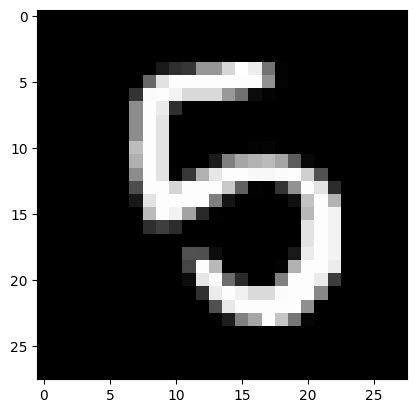

tensor([2, 1, 3, 3, 9, 8, 2, 0, 7, 1, 6, 2, 0, 7, 9, 4, 5, 7, 4, 7, 4, 1, 6, 8,
        7, 7, 5, 9, 2, 8, 9, 3, 5, 3, 3, 5, 7, 6, 3, 0, 9, 0, 1, 9, 2, 3, 4, 3,
        3, 0, 1, 3, 0, 6, 2, 2, 3, 7, 9, 0, 8, 9, 0, 9])
Imagenes:  torch.Size([28, 28])


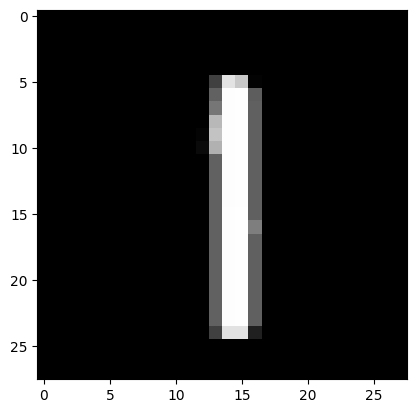

In [87]:
sample_img, _ = train_loader.__iter__().__next__()
one_img = sample_img[0][0]
sample_img[0].shape

for i in range(0,2):
  j, k = train_loader.__iter__().__next__()
  imagen = j[i][0]
  print(k)
  print("Imagenes: ",imagen.shape)
  plt.imshow(imagen, cmap='gray')
  plt.show()

### Patch Extraction

#### Neural Network / CNN / Backbone

In [88]:
#Copied from the file CNNPytorch
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.head = nn.Linear(64, 10)


    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # 28-3 = 25 + 1 = 26/2 = 13 ||
        x = self.pool(F.relu(self.conv2(x))) # 13-3 = 10 +1 = 11/2 = 5x5
        x = x.mean(dim=[2,3])
        return self.head(x)

class FeatureExtractorG(nn.Module):  # This is 'g' - The model without the head
    def __init__(self, base_model):
        super().__init__()
        self.conv1 = base_model.conv1
        self.conv2 = base_model.conv2
        self.pool = base_model.pool
        self.feat_dim = 64

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        return x

class ClassifierH(nn.Module):  # This is 'h' - the head with 10 classes
    def __init__(self, feature_extractor):
        super().__init__()
        #self.fc1 = base_model.fc1
        #self.fc2 = base_model.fc2
        #self.fc3 = base_model.fc3
        self.head = nn.Linear(feature_extractor.feat_dim, 10)

    def forward(self, x):
        #x = torch.flatten(x, 1)
        #x = F.relu(self.fc1(x))
        #x = F.relu(self.fc2(x))
        #return self.fc3(x)
        return self.head(x.mean(dim=[2,3])) # GAP → linear

In [89]:
# Charge the trained model
backbone = Net()
if torch.cuda.is_available():
    backbone.load_state_dict(torch.load('mnist_cnnPytorch.pt'))
else:
    print("CUDA not available, model charged in CPU cuz I'm poor :( ")
    backbone.load_state_dict(torch.load('mnist_cnnPytorch.pt',map_location=torch.device('cpu')))
backbone.eval()

g = FeatureExtractorG(backbone).to(device) #  Output: [batch,filters,h_size,w_size] ~ [64,64,5,5]
h = ClassifierH(g).to(device) # Head of the model


CUDA not available, model charged in CPU cuz I'm poor :( 


In [90]:
print("Procesing images...")

# Stratified sampling: 50 images per class
class_indices = [[] for _ in range(10)]
for idx in range(len(train_ds)):
    _, label = train_ds[idx]
    class_indices[label].append(idx)

samples_per_class = 100
stratified_indices = []
for class_label in range(10):
    stratified_indices.extend(class_indices[class_label][:samples_per_class])

train_subset = torch.utils.data.Subset(train_ds, stratified_indices)


images_list = []
for idx in range(len(train_subset)):
    img, _ = train_subset[idx]  # img is already a tensor from transforms.ToTensor()
    images_list.append(img)

# Stack all images into a single tensor
images_preprocessed = torch.stack(images_list).to(device)

print(f"images_preprocessed shape: {images_preprocessed.shape}")


Procesing images...
images_preprocessed shape: torch.Size([1000, 1, 28, 28])


In [91]:
import importlib
import craft.craft_torch
importlib.reload(craft.craft_torch)
from craft.craft_torch import Craft, torch_to_numpy

patch_size = 9
stride = 4
n_concepts = 20 #15-20

# Prepare images
images_list = []
labels_train = []
for idx in range(len(train_subset)):
    img, train_label = train_subset[idx]
    images_list.append(img)
    labels_train.append(train_label)

images_preprocessed = torch.stack(images_list).to(device)

print("labels_train: ", len(labels_train))
print("Images_list: ", len(images_list))

craft = Craft(input_to_latent = g,
              latent_to_logit = h,
              #full_model = backbone,
              number_of_concepts = n_concepts,
              patch_size = patch_size,
              batch_size = 64,
              device = device,)


# CRAFT will (1) create the patches, (2) find the concept
# and (3) return the crops (crops), the embedding of the crops (crops_u), and the concept bank (w)
#Apparently , we don't use crops in UCBM
crops, crops_u, w = craft.fit(images_preprocessed)
crops = np.moveaxis(torch_to_numpy(crops), 1, -1)


patches_per_image =  crops_u.shape[0]//images_preprocessed.shape[0]

print("Patches per image: ",patches_per_image)
print(crops.shape, crops_u.shape, w.shape)
print(f"Where {crops.shape[0]} is the total number of patches "\
      f"{crops.shape[1]} is the height and width of the image\n"\
      f"{crops_u.shape[1]} is the number of concepts "\
      f"and {w.shape[1]} is the number of features (output of backbone)")


# w, from CRAFT has a shape of [n_features, n_concepts]
# Save the concept bank (W matrix from NMF)
np.save("craft_concept_bank.npy", w)

labels_train:  1000
Images_list:  1000
Patches per image:  9
(9000, 9, 9, 1) (9000, 20) (20, 64)
Where 9000 is the total number of patches 9 is the height and width of the image
20 is the number of concepts and 64 is the number of features (output of backbone)


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [92]:
#Aidar idea
one_sample = crops_u[0:patches_per_image]
print(one_sample.shape)

#Dimensionality reduction:
one_sample_vector = one_sample.ravel()
print("One sample vector: ", len(one_sample_vector))

(9, 20)
One sample vector:  180


labels_train:  1000
patches_per_image:  9
Concept_activations.shape;  (9000, 64)
Top crops shape:  (5, 9, 9)


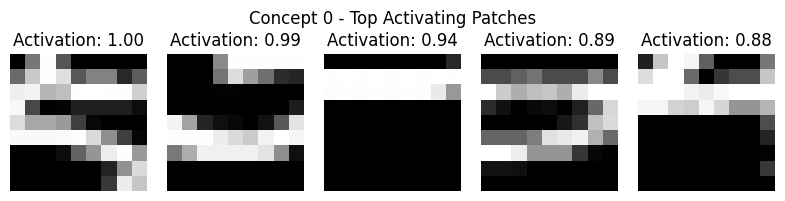

Top crops shape:  (5, 9, 9)


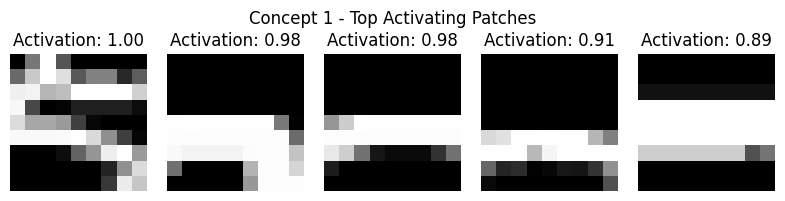

Top crops shape:  (5, 9, 9)


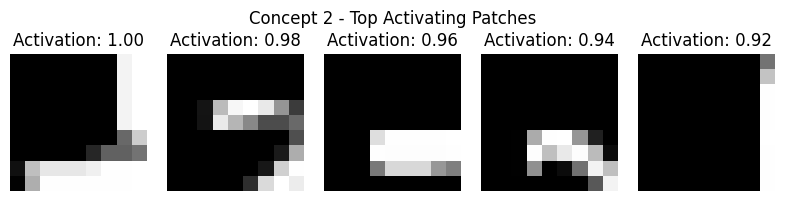

Top crops shape:  (5, 9, 9)


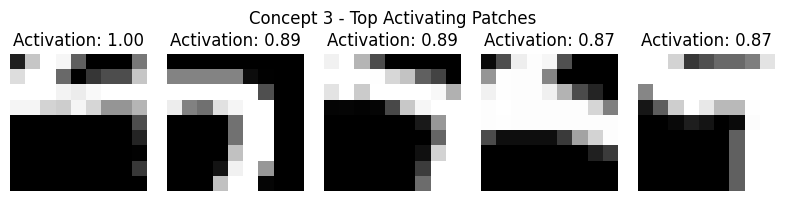

Top crops shape:  (5, 9, 9)


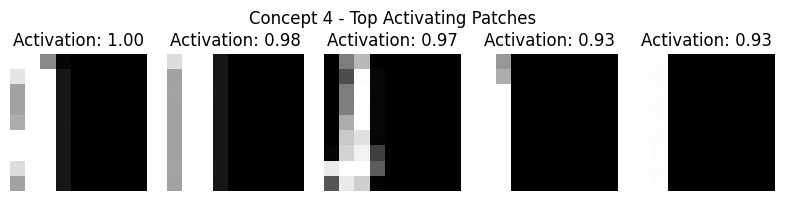

Top crops shape:  (5, 9, 9)


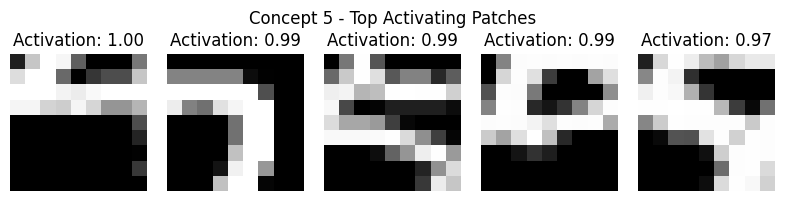

Top crops shape:  (5, 9, 9)


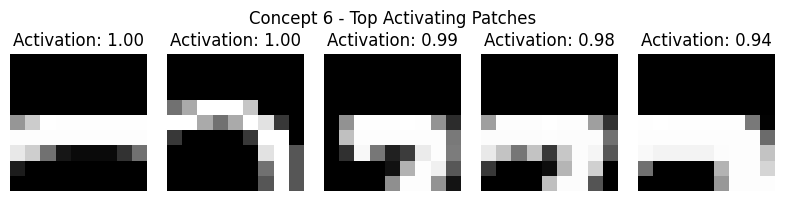

Top crops shape:  (5, 9, 9)


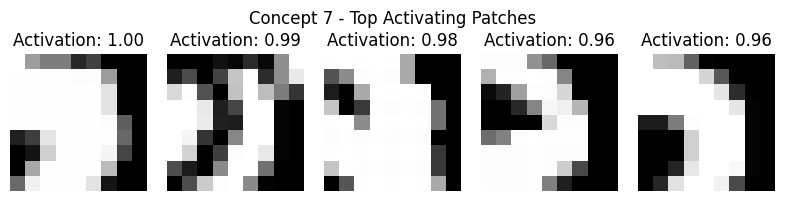

Top crops shape:  (5, 9, 9)


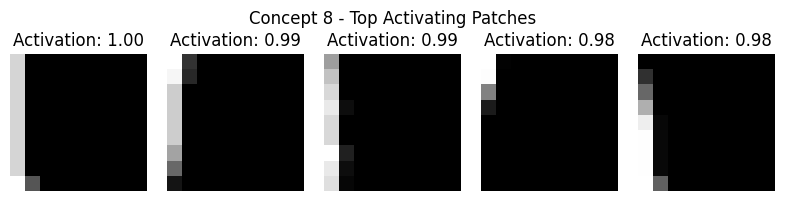

Top crops shape:  (5, 9, 9)


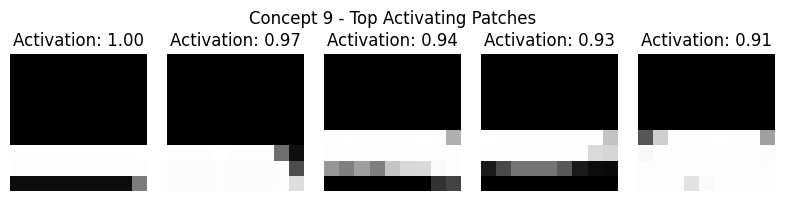

In [93]:
# Which concepts activate for each patch?
concept_activations = crops_u @ w  # [n_patches, n_concepts]

#Normalization
concept_activations= (concept_activations - concept_activations.min(axis=0)) / (concept_activations.max(axis=0) - concept_activations.min(axis=0) + 1e-8)

print("labels_train: ", len(labels_train))
print("patches_per_image: ", patches_per_image)

print("Concept_activations.shape; ", concept_activations.shape)
# Show top patches for each concept
for concept_id in range(min(10, n_concepts)):
    top_patch_ids = np.argsort(concept_activations[:, concept_id])[-5:]


    fig, axes = plt.subplots(1, 5, figsize=(8, 2))
    print("Top crops shape: ", crops[top_patch_ids, :, :, 0].shape)
    for idx, patch_id in enumerate(top_patch_ids[::-1]):
        axes[idx].imshow(crops[patch_id, :, :, 0], cmap='gray')
        axes[idx].set_title(f"Activation: {concept_activations[patch_id, concept_id]:.2f}")
        axes[idx].axis('off')

    plt.suptitle(f"Concept {concept_id} - Top Activating Patches")
    plt.tight_layout()
    plt.show()

### Tree Classifier


In [94]:
class PDataset(Dataset):
    def __init__(self, *its, list_to_tensor: bool = True):
        assert len(its) > 0, "At least one sequence must be given"

        # torch.is_tensor() is already covered by hasattr(__len__), so we simplify get_length
        first_len = len(its[0]) if hasattr(its[0], '__len__') else its[0].shape[0]
        assert all(
            (len(it) if hasattr(it, '__len__') else it.shape[0]) == first_len for it in its
        ), "Provided iterables need to be the same size."

        self.its = its
        self.list_to_tensor = list_to_tensor

    def __len__(self):
        # Inline the length logic — avoids method call overhead on every DataLoader tick
        return len(self.its[0]) if hasattr(self.its[0], '__len__') else self.its[0].shape[0]

    def __getitem__(self, idx):
        if not self.list_to_tensor:
            return [it[idx] for it in self.its]

        res = []
        for it in self.its:
            item = it[idx]
            # Consolidate: convert anything that isn't already a tensor
            if not torch.is_tensor(item):
                # Convert scalars (like targets) to tensors
                item = torch.tensor(item)
            res.append(item)
        return res # Returns [embedding, target] [cite: 31]


#https://github.com/lmb-freiburg/ucbm/blob/main/concept_auxiliaries/concept_auxiliaries.py

def raw_concept_sims(
    h: Union[np.ndarray, torch.Tensor], #h = np.load("craft_concept_bank.npy")
    dataset: Dataset,
    backbone: Union[nn.Module, Callable],
    batch_size: int,
    device: Literal["cuda", "cpu"],
    saved_activation_path: Optional[str] = None,
    data_label: Optional[str] = None,
    mean: Optional[torch.Tensor] = None,
    std: Optional[torch.Tensor] = None,
) -> torch.Tensor:

    save = data_label is not None
    if save:
        assert saved_activation_path is not None, (
            "`saved_activation_path` must be provided when `data_label` is set."
        )
        saving_dir = path.join(saved_activation_path, f"saved_{data_label}_activations")
        os.makedirs(saving_dir, exist_ok=True)

    # --- Prepare CAVs --- h from h = np.load("craft_concept_bank.npy")
    if not torch.is_tensor(h):
        h = torch.tensor(h, dtype=torch.float32)
    h = h.to(device)
    norms = torch.linalg.norm(h, dim=1, keepdim=True)
    h = h / norms.clamp(min=1e-8)  # clamp avoids division by zero for dead CAVs

    # --- Prepare backbone ---
    if isinstance(backbone, nn.Module):
        backbone.to(device)
        backbone.eval()

    # --- Compute concept similarities ---
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    all_activations = []

    for i, (X_batch, _) in enumerate(tqdm(data_loader, leave=False)):
        out = backbone(X_batch.to(device))

        # Global average pool spatial dimensions (e.g. conv feature maps)
        if out.ndim == 4:
            out = out.mean(dim=(2, 3))


        # Normalize activations, cast to CAV dtype, project onto CAVs
        out_norm = torch.linalg.norm(out, dim=1, keepdim=True).clamp(min=1e-8)
        out = (out / out_norm).to(h.dtype)
        out = torch.matmul(out, h.T).cpu()

        #Out of the backbone before the normalization:  torch.Size([128, 64, 5, 5])
        #Out of the normalization, before the matmul:  torch.Size([128, 64])
        #Result of matmul[output*n_concepts]:  torch.Size([128, 30])



        all_activations.append(out)

        if save:
            torch.save(out, path.join(saving_dir, f"{data_label}_{i}.pt"))

    # --- Concatenate and optionally normalize ---
    full_tensor = torch.cat(all_activations)


    return full_tensor


#https://github.com/lmb-freiburg/ucbm/blob/9d403a87398e5b538d75ac28ef1114c695a8371c/data_loader.py#L9
def load_data(subset, parent_dataset):
    if isinstance(parent_dataset, torch.utils.data.ConcatDataset):
        subset.classes = parent_dataset.datasets[0].classes
        all_targets = torch.cat([d.targets for d in parent_dataset.datasets])
    else:
        subset.classes = parent_dataset.classes
        all_targets = parent_dataset.targets
    subset.targets = all_targets[subset.indices]
    return subset

train_data = load_data(train_ds, full_dataset)
val_data   = load_data(val_ds, full_dataset)
test_data  = load_data(test_ds, full_dataset)

In [95]:
cls_save_name= "topk_seed_0"
device = "cuda" if torch.cuda.is_available() else "cpu"
dataset = "MNIST"

try:
  h = np.load("craft_concept_bank.npy") #this is the h.py <----------------    10 CONCEPT BANK
  print("Concepts loaded")
except NameError:
  print("No Concepts file found", NameError)


#Normalization
h_tensor = torch.tensor(h, dtype=torch.float32)
h_tensor = F.normalize(h_tensor, p=2, dim=1) # Normalización L2 estricta
h = h_tensor.numpy()


act_path = "./mnist_activations"


Concepts loaded


In [113]:
class ConceptBasedDecisionTree:
  def __init__(self,
               backbone,
               h: Union [torch.Tensor, np.ndarray],
               crops: np.ndarray,
               concept_activations: np.ndarray | torch.Tensor,
               max_depth: int,
               min_samples_split: int,
               batch_size: int,
               device: Literal['cuda', 'cpu'] ):


        self._backbone = backbone # we have it, FeatureExtractor
        if not torch.is_tensor(h):
            h = torch.tensor(h) # h is the concepts from h = np.load("craft_concept_bank.npy")
        self.n_concepts = h.shape[0]  #shape (10, 64)
        self._h = h.to(device)
        self._h = self._h / torch.norm(self._h, dim=1, keepdim=True) #Normalize the concept


        self.crops = crops
        self.concept_activations = concept_activations
        self._batch_size = batch_size #we have it from the DataLoader = 64
        self._device = device #GPU. Thanks google

        print("Crops shape", crops.shape)
        self.patch_h, self.patch_w = crops.shape[0], crops.shape[1]
        self.channels = crops.shape[3] if crops.ndim == 4 else 1

        self.top_concept_patches = self._extract_concept_patches()
        print("Concept patches shape: ", self.top_concept_patches.shape)

        # Initialize decision tree
        self.tree = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
        )

        self.is_fitted = False
        self.feature_names = [f"Concept_{i}" for i in range(self.n_concepts)]
        self.class_names = [str(i) for i in range(10)]  # For MNIST 0-9


  def _extract_concept_patches(self) -> np.ndarray:
        """
        Extract the top patch for each concept based on concept activations.

        Returns:
            Array of shape [n_concepts, patch_h, patch_w] (grayscale)
        """
        top_concept_patches = []

        for concept_id in range(self.n_concepts):
            activations = self.concept_activations[:, concept_id]
            top_patch_idx = np.argmax(activations)

            # Get the patch
            top_patch = self.crops[top_patch_idx]  # [patch_h, patch_w, channels]
            # Convert to grayscale if needed
            if self.channels == 1:
                top_patch = top_patch.squeeze()  # [patch_h, patch_w]
            elif self.channels == 3:
                # Convert RGB to grayscale
                top_patch = np.mean(top_patch, axis=2)  # [patch_h, patch_w]

            top_concept_patches.append(top_patch)

        return np.array(top_concept_patches)  # [n_concepts, patch_h, patch_w]


  @torch.no_grad()
  def _get_concept_embeddings(self,dataset: Dataset,
                                saved_activation_path: Optional[str] = None,
                                data_label: Optional[str] = None,
                                normalize=False) \
                                    -> Dataset[torch.Tensor]:


        return raw_concept_sims(self._h,dataset,
                                self._backbone,self._batch_size,
                                self._device,saved_activation_path,
                                data_label)


  def train(self, data_ds: ImageFolder):
        """
        Train the decision tree on concept activations.
        Args:
            data_ds: Array of shape [n_samples, n_concepts]

        """
        embeddings = self._get_concept_embeddings(
            data_ds,
            act_path,
            "train"
        )

        num_embeddings = len(embeddings)
        # --- DataLoader over (embeddings, targets) pairs ---
        dset = PDataset(embeddings, data_ds.targets[:num_embeddings])
        data_loader = DataLoader(dset, self._batch_size, shuffle=True, num_workers=num_workers)

        # --- Training loop REPLACED ---

        all_gated = []
        all_labels = []

        with torch.no_grad():
            for X_batch, y_batch in tqdm(data_loader, leave=False):
                X_batch = X_batch.to(self._device)
                X_batch = (X_batch - X_batch.mean(dim=0)) / (X_batch.std(dim=0) + 1e-8)
                after_gate = X_batch.detach()


                all_gated.append(after_gate.cpu())
                all_labels.append(y_batch.cpu())

        all_gated = torch.cat(all_gated, dim=0).numpy()
        all_labels = torch.cat(all_labels, dim=0).numpy()
        print("all_gated: ", all_gated.shape)
        print("all_labels: ", all_labels.shape)


        print("Training Decision Tree on Concept Activations...")
        print(f"Embeddings Shape: {embeddings.shape}") #<--- not Concept_activations IS embeddings
        print(f"  Classes: {np.unique(labels)}")
        self.tree.fit(all_gated, all_labels)
        self.is_fitted = True
        train_acc = self.tree.score(all_gated, all_labels)
        print(f"\nTraining Accuracy: {train_acc*100:.2f}%")


        return {
            'accuracy': train_acc
        }


  def evaluate(self, data_ds: np.ndarray) -> Dict[str, float]:
        """
        Evaluate the tree on test data.

        Returns:
            Dictionary with accuracy metrics
        """
        if not self.is_fitted:
            raise ValueError("Tree must be trained first!")

        embeddings = self._get_concept_embeddings(
            data_ds,
            act_path,
            "test"
        )

        num_embeddings = len(embeddings)
        dset = PDataset(embeddings, data_ds.targets[:num_embeddings])
        data_loader = DataLoader(dset, self._batch_size, shuffle=True, num_workers=num_workers)

        all_gated = []
        all_labels = []

        with torch.no_grad():
            for X_batch, y_batch in tqdm(data_loader, leave=False):
                X_batch = X_batch.to(self._device)
                X_batch = (X_batch - X_batch.mean(dim=0)) / (X_batch.std(dim=0) + 1e-8)
                after_gate = X_batch.detach()
                #after_gate, _ = ph_cbm._classifier(X_batch) #return out, gated, x
                all_gated.append(after_gate.cpu())
                all_labels.append(y_batch.cpu())

        all_gated = torch.cat(all_gated, dim=0).numpy()
        all_labels = torch.cat(all_labels, dim=0).numpy()
        print("all_gated: ", all_gated.shape)
        print("all_labels: ", all_labels.shape)

        predictions = self.tree.predict(all_gated)
        acc = accuracy_score(all_labels, predictions)
        print(f"Test Accuracy: {100 * acc:.2f}%")


        return {
            'accuracy': acc,
            'predictions': predictions,
            'confusion_matrix': confusion_matrix(all_labels, predictions)
        }


  def get_decision_path(self, concept_activation: np.ndarray) -> Tuple[List[int], List[float], int]:
        """
        Get the decision path taken by the tree for a single sample.

        Args:
            concept_activation: Array of shape [n_concepts,]

        Returns:
            (node_indices, feature_values_at_nodes, predicted_class)
        """
        if not self.is_fitted:
            raise ValueError("Tree must be trained first!")

        # Get decision path
        decision_path = self.tree.decision_path([concept_activation]).indices[0]

        # Get the values of concepts at each decision node
        feature_values = []
        for node_idx in decision_path:
            feature_idx = self.tree.tree_.feature[node_idx]
            if feature_idx >= 0:  # Not a leaf node
                feature_values.append(concept_activation[feature_idx])
            else:
                feature_values.append(None)

        predicted_class = self.tree.predict([concept_activation])[0]

        return list(decision_path), feature_values, predicted_class

  def predict(self, concept_activations: np.ndarray) -> np.ndarray:
        """Predict class labels."""
        return self.tree.predict(concept_activations)

  def get_feature_at_node(self, node_idx: int) -> int:
        """Get the feature (concept) used for splitting at a node."""
        return self.tree.tree_.feature[node_idx]

  def get_threshold_at_node(self, node_idx: int) -> float:
        """Get the threshold value for splitting at a node."""
        return self.tree.tree_.threshold[node_idx]

  def get_node_class(self, node_idx: int) -> int:
        """Get the most common class at a node."""
        value = self.tree.tree_.value[node_idx][0]
        return np.argmax(value)


  def visualize_tree_structure(self, figsize: Tuple[int, int] = (20, 12)):
        """
        Visualize the tree structure with concept patches at each node.
        """
        if not self.is_fitted:
            raise ValueError("Tree must be trained first!")

        fig, ax = plt.subplots(figsize=figsize)
        self._draw_tree_recursive(0, ax, x=0.5, y=1.0, dx=0.25)

        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.1, 1.1)
        ax.axis('off')
        plt.title("Decision Tree with Concept Patches", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

  def _draw_tree_recursive(self, node_idx: int, ax, x: float, y: float, dx: float):
        """Recursively draw tree nodes with patches."""

        # Draw node box with patch
        feature_idx = self.tree.tree_.feature[node_idx]


        if feature_idx >= 0:  # Not a leaf
            # Decision node
            concept_patch = self.top_concept_patches[feature_idx]
            threshold = self.tree.tree_.threshold[node_idx]

            # Draw patch as node
            patch_img = torch.from_numpy(concept_patch).float()
            if patch_img.dim() == 2:  # Grayscale
                patch_img = patch_img.unsqueeze(0)

            # Add patch to plot at position (x, y)
            ax_inset = ax.inset_axes([x-0.04, y-0.08, 0.08, 0.08])
            # Convert to numpy
            img_data = patch_img.numpy()

            # If it's a 1D vector (like shape [20]), force it to be a 2D shape [1, 20] so imshow can draw it
            if img_data.ndim == 1:
                img_data = np.expand_dims(img_data, axis=0)
            # If it's a batch of images, safely grab the first one
            elif img_data.ndim >= 3 and img_data.shape[0] > 1:
                img_data = img_data[0]
            # If it's a single 3D image [C, H, W], transpose it to [H, W, C] for matplotlib
            elif img_data.ndim == 3 and img_data.shape[0] in [1, 3, 4]:
                img_data = np.transpose(img_data, (1, 2, 0))

            # Plot with aspect='auto' so 1D heatmaps fill the square nicely
            ax_inset.imshow(img_data, cmap='gray', aspect='auto')



            ax_inset.set_title(f"C{feature_idx}\n<{threshold:.2f}", fontsize=8)
            ax_inset.axis('off')

            # Draw edges to children
            left_child = self.tree.tree_.children_left[node_idx]
            right_child = self.tree.tree_.children_right[node_idx]

            if left_child != -1:
                x_left = x - dx
                y_left = y - 0.2
                ax.arrow(x, y-0.04, x_left-x, y_left-y+0.04,
                        head_width=0.02, head_length=0.02, fc='black', ec='black', alpha=0.6)
                self._draw_tree_recursive(left_child, ax, x_left, y_left, dx/2)

            if right_child != -1:
                x_right = x + dx
                y_right = y - 0.2
                ax.arrow(x, y-0.04, x_right-x, y_right-y+0.04,
                        head_width=0.02, head_length=0.02, fc='black', ec='black', alpha=0.6)
                self._draw_tree_recursive(right_child, ax, x_right, y_right, dx/2)
        else:
            # Leaf node
            class_pred = self.get_node_class(node_idx)
            rect = FancyBboxPatch((x-0.04, y-0.04), 0.08, 0.08,
                                 boxstyle="round,pad=0.01",
                                 edgecolor='green', facecolor='lightgreen', linewidth=2)
            ax.add_patch(rect)
            ax.text(x, y, str(class_pred), ha='center', va='center',
                   fontsize=10, fontweight='bold')

  @torch.no_grad()
  def get_evaluation_metric(self,
                              dataset: ImageFolder,
                              metric: list[Literal["acc", "auprc", "auroc", "auprc_pc"]] = ["acc"],
                              saved_activation_path: Optional[str] = None,
                              data_label: Optional[str] = None) \
                                -> dict[str, float]:


        if isinstance(dataset, Subset):
            parent = dataset.dataset
            indices = dataset.indices
        else:
            parent = dataset
            indices = None

        if isinstance(parent, ConcatDataset):
            all_targets = torch.cat([d.targets for d in parent.datasets])
        else:
            all_targets = parent.targets

        if indices is not None:
            current_targets = all_targets[indices]
        else:
            current_targets = all_targets

        # Load the concept activations.
        embeddings = self._get_concept_embeddings(dataset, saved_activation_path)


        dset = TensorDataset(embeddings.cpu(), current_targets.cpu())
        data_loader = DataLoader(dset, batch_size=self._batch_size, shuffle=False, num_workers=4)

        y_pred = []
        y_true = []

        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(self._device)
            X_batch = (X_batch - X_batch.mean(dim=0)) / (X_batch.std(dim=0) + 1e-8)
            after_gate = X_batch.detach()

            y_pred.append(after_gate.cpu())
            y_true.append(y_batch.cpu())


        y_pred = torch.cat(y_pred)
        y_true = torch.cat(y_true)

        preds = self.tree.predict(y_pred)
        acc = accuracy_score(y_true, preds)

        if "acc" in metric:
            return {"acc": acc}

  def save_to_file(self, filepath: str, filename: str):
     def get_backbone():
        try:
            return self._backbone.cpu()
        except AttributeError:
            return None

        path = os.path.join(filepath, filename)
        torch.save(
            {
                "backbone": get_backbone(),
                "batch_size": self._batch_size,
                "num_concepts": self._num_concepts,
                "w": self._h.detach().cpu(),
            }, path)


  def get_info_dict(self,
                      training_data: ImageFolder,
                      test_data: ImageFolder,
                      val_data: ImageFolder,
                      act_bank_path: str,
                      images_preprocessed: int,
                      patch_size: int,
                      total_patches: int,
                      metrics = ["acc", "auprc", "auprc_pc", "auroc"]) -> dict:


        data = dict()
        data["amount of concepts"] = int(self._h.shape[0])
        data["amount of classes"] = len(test_data.classes)
        data["amount of samples"] = images_preprocessed
        data["samples per class"] = images_preprocessed//len(test_data.classes)
        data["total patches"] = total_patches
        data["patch_size"] = int(patch_size)
        first_sample_features, first_sample_label = training_data[0]
        print("\ntraining_data: ", first_sample_features.shape, first_sample_label)
        print("test_data: ", len(test_data))
        print("val_data: ", len(val_data))
        train_res = self.get_evaluation_metric(training_data, metrics, act_bank_path, "train")
        test_res = self.get_evaluation_metric(test_data, metrics, act_bank_path, "test")
        val_res = self.get_evaluation_metric(val_data, metrics, act_bank_path, "val")
        print("train_res: ", train_res)
        print("test_res: ", test_res)
        print("val_res: ", val_res)

        if "acc" in metrics and "acc" in train_res:
            data["train acc"] = train_res["acc"]
            data["test acc"] = test_res["acc"]

        data["val_acc"] = val_res['acc']

        return data

def create_confusion_matrix_visualization(predictions: np.ndarray, labels: np.ndarray):
    """
    Create a confusion matrix heatmap.
    """
    cm = confusion_matrix(labels, predictions)

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=range(10), yticklabels=range(10))
    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_title('Confusion Matrix', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()


def visualize_decision_journey(
    image: torch.Tensor,
    concept_activation: np.ndarray,
    concept_patches: np.ndarray,
    tree: ConceptBasedDecisionTree,
    true_label: int,
    predicted_label: int,
    image_index: int = None
):
    """
    Visualize the decision journey for a single image through the tree.

    Args:
        image: Input image tensor [1, H, W] or [3, H, W]
        concept_activation: Concept activation vector [n_concepts,]
        concept_patches: Array of concept patches
        tree: Trained ConceptBasedDecisionTree
        true_label: Ground truth label
        predicted_label: Model's predicted label
        image_index: Optional index for display
    """

    # Get decision path
    node_path, feature_values, tree_prediction = tree.get_decision_path(concept_activation)

    # Prepare figure
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 4, hspace=0.4, wspace=0.3)

    # ============ Top Left: Original Image ============
    ax_img = fig.add_subplot(gs[0, 0])
    img_display = image.permute(1, 2, 0).numpy() if image.dim() == 3 else image.numpy()
    if img_display.shape[-1] == 1 or image.shape[0] == 1:
        ax_img.imshow(img_display.squeeze(), cmap='gray')
    else:
        ax_img.imshow(img_display)
    ax_img.set_title(f"Input Image\nIdx: {image_index if image_index else '?'}", fontweight='bold')
    ax_img.axis('off')

    # ============ Top Middle: Prediction Info ============
    ax_pred = fig.add_subplot(gs[0, 1])
    ax_pred.axis('off')
    correct = "✓" if true_label == predicted_label else "✗"
    pred_text = f"""
    PREDICTION SUMMARY
    ─────────────────────
    True Label: {true_label}
    Predicted: {predicted_label} {correct}
    Confidence: {concept_activation.max():.3f}
    Tree Depth: {len(node_path)}
    """
    ax_pred.text(0.1, 0.5, pred_text, fontsize=11, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # ============ Top Right: Concept Activations ============
    ax_concepts = fig.add_subplot(gs[0, 2:])
    sorted_indices = np.argsort(concept_activation)[::-1]
    top_k = 8
    ax_concepts.barh(range(top_k), concept_activation[sorted_indices[:top_k]])
    ax_concepts.set_yticks(range(top_k))
    ax_concepts.set_yticklabels([f"C{idx}" for idx in sorted_indices[:top_k]])
    ax_concepts.set_xlabel("Activation Value")
    ax_concepts.set_title("Top Concept Activations", fontweight='bold')
    ax_concepts.invert_yaxis()

    # ============ Middle: Decision Path with Patches ============
    n_nodes = len(node_path)
    cols_per_node = max(1, 4 // min(n_nodes, 4))

    for i, node_idx in enumerate(node_path):
        ax = fig.add_subplot(gs[1, i % 4])

        feature_idx = tree.get_feature_at_node(node_idx)

        if feature_idx >= 0:  # Decision node
            concept_patch = concept_patches[feature_idx]
            threshold = tree.get_threshold_at_node(node_idx)
            activation = concept_activation[feature_idx]

            # Display patch
            if isinstance(concept_patch, np.ndarray):
                patch_np = concept_patch
            else:
                patch_np = concept_patch.cpu().numpy() if hasattr(concept_patch, 'cpu') else concept_patch

            ax.imshow(patch_np, cmap='gray')

            # Decision direction
            direction = "LEFT" if activation < threshold else "RIGHT"
            color = 'lightcoral' if direction == "LEFT" else 'lightgreen'

            ax.set_title(f"Node {node_idx}\nC{feature_idx} = {activation:.3f}\nThreshold: {threshold:.3f}\n→ {direction}",
                        fontweight='bold', fontsize=9, bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))
            ax.axis('off')
        else:
            # Leaf node
            class_at_leaf = tree.get_node_class(node_idx)
            ax.text(0.5, 0.5, f"LEAF\nClass: {class_at_leaf}",
                   ha='center', va='center', fontsize=14, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
            ax.set_title(f"Node {node_idx} (Leaf)", fontweight='bold')
            ax.axis('off')

    # ============ Bottom: Decision Path Summary ============
    ax_summary = fig.add_subplot(gs[2, :])
    ax_summary.axis('off')

    path_text = "DECISION PATH:\n"
    path_text += "─" * 80 + "\n"

    for i, node_idx in enumerate(node_path):
        feature_idx = tree.get_feature_at_node(node_idx)
        if feature_idx >= 0:
            activation = concept_activation[feature_idx]
            threshold = tree.get_threshold_at_node(node_idx)
            direction = "LEFT (<)" if activation < threshold else "RIGHT (≥)"
            path_text += f"Step {i}: Node {node_idx} → Concept {feature_idx} | "
            path_text += f"Activation: {activation:.3f} | Threshold: {threshold:.3f} | {direction}\n"
        else:
            class_at_leaf = tree.get_node_class(node_idx)
            path_text += f"Step {i}: Node {node_idx} (LEAF) → Predicted Class: {class_at_leaf}\n"

    ax_summary.text(0.05, 0.95, path_text, fontsize=9, family='monospace',
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.suptitle("Decision Tree Journey Through Concepts", fontsize=16, fontweight='bold', y=0.995)
    plt.show()


In [114]:
print("="*70)
print("STEP 1: Compute Concept Activations")
print("="*70)

# Compute concept activations from CRAFT
concept_activations = crops_u @ w  # [n_patches, n_concepts]

print(f"✓ Crops shape: {crops_u.shape}")
print(f"✓ Concept activations shape: {concept_activations.shape}")
print(f"✓ Number of concepts: {concept_activations.shape[1]}")

print("\n" + "="*70)
print("STEP 2: Split Data by Your Dataset Splits")
print("="*70)

# Get sizes to mesure fit them
n_train = len(train_subset)

print(f"Train size: {n_train}")

print("\n" + "="*70)
print("STEP 3: Create and Train Decision Tree")
print("="*70)

print(f"✓ Training set size: {train_data}")

#ph_cbm = UCBM(backbone=g, h=h, batch_size= 128, device=device)


#ph_cbm.fit(train_data, saved_activation_path = act_path, test_set = test_data)

tree = ConceptBasedDecisionTree(
      backbone=g,
      h=h,
      crops=crops,  # Use training crops
      concept_activations=concept_activations,  # For extracting top patches
      max_depth=5,
      min_samples_split=50,
      device=device,
      batch_size=64
  )

print(f"✓ Tree created")
print(f"✓ Number of concepts: {tree.n_concepts}")
print(f"✓ Patch dimensions: {tree.patch_h}x{tree.patch_w}")


#print(f"\nTraining on {embeddings.shape[0]} samples...")
train_metrics = tree.train(train_data)
print(f"✓ Training complete!")

STEP 1: Compute Concept Activations
✓ Crops shape: (9000, 20)
✓ Concept activations shape: (9000, 64)
✓ Number of concepts: 64

STEP 2: Split Data by Your Dataset Splits
Train size: 1000

STEP 3: Create and Train Decision Tree
✓ Training set size: <torch.utils.data.dataset.Subset object at 0x7e118f08da00>
Crops shape (9000, 9, 9, 1)
Concept patches shape:  (20, 9, 9)
✓ Tree created
✓ Number of concepts: 20
✓ Patch dimensions: 9000x9


all_gated:  (56000, 20)
all_labels:  (56000,)
Training Decision Tree on Concept Activations...
Embeddings Shape: torch.Size([56000, 20])
  Classes: [0 1 2 3 4 5 6 7 8 9]

Training Accuracy: 60.89%
✓ Training complete!


In [98]:
print("\n" + "="*70)
print("STEP 4: Evaluate Tree")
print("="*70)

# Validation
val_metrics = tree.evaluate(val_ds)
print(f"✓ Val Accuracy: {val_metrics['accuracy']*100:.2f}%")

# Test
test_metrics = tree.evaluate(test_ds)
print(f"✓ Test Accuracy: {test_metrics['accuracy']*100:.2f}%")


STEP 4: Evaluate Tree


all_gated:  (7000, 20)
all_labels:  (7000,)
Test Accuracy: 59.23%
✓ Val Accuracy: 59.23%


all_gated:  (7000, 20)
all_labels:  (7000,)
Test Accuracy: 60.36%
✓ Test Accuracy: 60.36%


In [99]:
print(f"Number of nodes in the tree: {tree.tree.tree_.node_count}")
print("ps que hay adentro del arbol?", tree.tree.tree_.feature)
print(tree.tree.tree_.threshold.shape)
print(tree.tree.tree_.children_left.shape)
print(tree.tree.tree_.children_right.shape)
print(tree.tree.tree_.n_node_samples.shape)
print(tree.tree.tree_.value.shape)
print(tree.tree.tree_.impurity)
print(tree.tree.tree_.max_depth)

Number of nodes in the tree: 55
ps que hay adentro del arbol? [14 18  3 12 -2  7 -2 -2  6  4 -2 -2 -2 12  2 12 -2 -2 12 -2 -2 13 -2 -2
 11 15  6  9 -2 -2  2 -2 -2  6  3 -2 -2 10 -2 -2  4  6  3 -2 -2 12 -2 -2
  2  4 -2 -2  6 -2 -2]
(55,)
(55,)
(55,)
(55,)
(55, 1, 10)
[0.89970684 0.15366331 0.50663822 0.3434     0.61111111 0.11689471
 0.         0.0728125  0.28993058 0.07522703 0.44444444 0.05111531
 0.67913832 0.05059852 0.03705545 0.02305805 0.00912874 0.32525952
 0.50802235 0.23668639 0.62821992 0.55410226 0.26412849 0.21453287
 0.89108818 0.66913273 0.61000988 0.44769122 0.3291218  0.75063277
 0.71415855 0.54212869 0.58761094 0.46253669 0.25118814 0.15858523
 0.70566209 0.72383007 0.55327197 0.61114668 0.87661296 0.79015429
 0.75317097 0.44037189 0.74608666 0.68950377 0.49254084 0.74711501
 0.84276756 0.78466887 0.79684551 0.49619057 0.73452347 0.71944609
 0.58385684]
5


STEP 5: Visualize Tree Structure


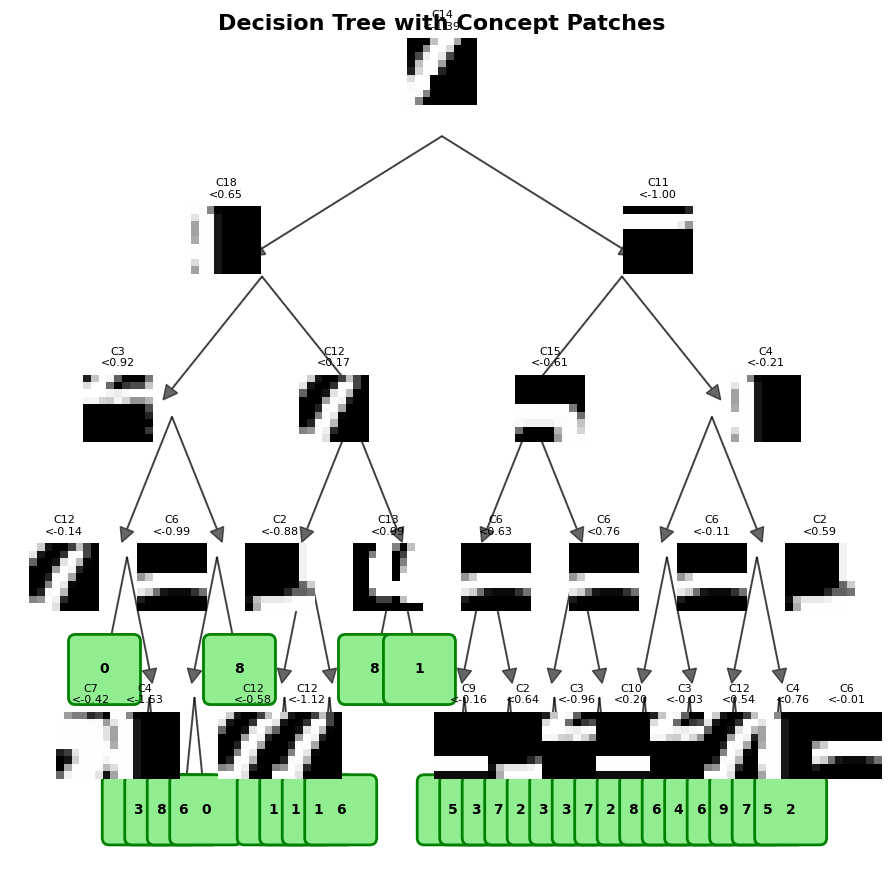

In [100]:
print("STEP 5: Visualize Tree Structure")
print("="*70)
tree.visualize_tree_structure(crops.shape[1:3])



STEP 6: Visualize Confusion Matrix


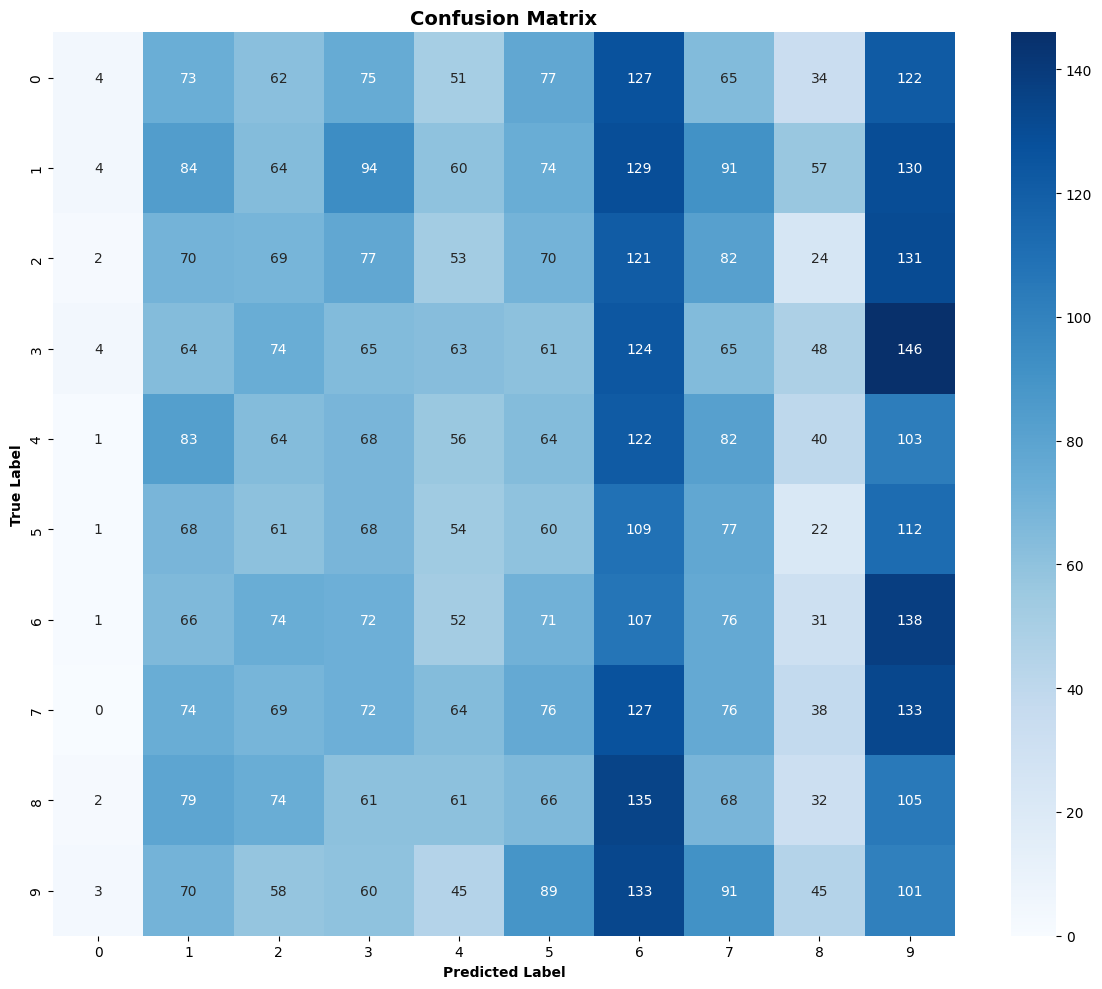

In [101]:
print("\n" + "="*70)
print("STEP 6: Visualize Confusion Matrix")
print("="*70)

labels_test = torch.cat([labels for _, labels in test_loader]).tolist()

create_confusion_matrix_visualization(
   test_metrics['predictions'],
   labels_test
)

#tree.tree.score(test_ds,labels_test),
data_dict =  {
        'train_accuracy': train_metrics['accuracy'],
        'val_accuracy': val_metrics['accuracy'],
        'test_accuracy': test_metrics['accuracy'],
}

In [120]:
image_index = 0

test_image = test_ds[image_index][0]
true_label = test_labels[image_index]

single_sample_ds = Subset(test_ds, [image_index])  # Use test_ds consistently
sample_embedding = tree._get_concept_embeddings(single_sample_ds, act_path, data_label="single_test")

test_activation = sample_embedding[0].cpu().numpy()

pred_label = tree.predict(test_activation.reshape(1, -1))[0]

# Get concept patches from the internal decision tree
concept_patches_array = tree.concept_patches

visualize_decision_journey(
    image=test_image,
    concept_activation=test_activation,
    concept_patches=concept_patches_array,
    tree=tree._tree,
    true_label=true_label,
    predicted_label=pred_label,
    image_index=image_index
)

AttributeError: 'ConceptBasedDecisionTree' object has no attribute 'concept_patches'

In [102]:
def visualize_digit_seven(tree, data_dict, test_subset, n_examples=3):
    """
    Show decision journeys for digit 7.

    Args:
        tree: Trained ConceptBasedDecisionTree
        data_dict: Data dictionary from integrate_decision_tree_with_craft
        test_subset: Your test dataset
        n_examples: How many examples to show
    """

    print("\n" + "="*70)
    print("VISUALIZING DECISION JOURNEYS FOR DIGIT '7'")
    print("="*70)

    test_labels = data_dict['labels_test']
    concept_act_test = data_dict['concept_activations_test']

    # Find indices where label is 7
    seven_indices = np.where(test_labels == 7)[0]

    print(f"Found {len(seven_indices)} examples of digit 7 in test set")

    if len(seven_indices) == 0:
        print("No digit 7 found in test set!")
        return

    # Show up to n_examples
    for example_num in range(min(n_examples, len(seven_indices))):
        idx = seven_indices[example_num]

        # Get image from test_subset
        test_image, true_label = test_subset[idx]

        # Get concept activation
        concept_activation = concept_act_test[idx]

        # Get prediction
        pred_label = tree.predict(concept_activation.reshape(1, -1))[0]

        print(f"\n  Example {example_num + 1}:")
        print(f"    Index: {idx}")
        print(f"    True Label: {true_label}")
        print(f"    Predicted: {pred_label}")
        print(f"    Correct: {'✓' if true_label == pred_label else '✗'}")

        # Visualize the journey
        visualize_decision_journey(
            image=test_image,
            concept_activation=concept_activation,
            concept_patches=tree.concept_patches,
            tree=tree,
            true_label=int(true_label),
            predicted_label=int(pred_label),
            image_index=idx
        )

In [103]:
def explain_decision_for_digit(tree, data_dict, test_subset,  digit=7,
    example_num=0
):
    """
    Print detailed decision path for a specific digit example.

    Args:
        tree: Trained tree
        data_dict: Data dictionary
        test_subset: Test dataset
        digit: Which digit (0-9)
        example_num: Which example of that digit (0, 1, 2, ...)
    """

    test_labels = data_dict['labels_test']
    concept_act_test = data_dict['concept_activations_test']

    # Find examples of this digit
    digit_indices = np.where(test_labels == digit)[0]

    if len(digit_indices) <= example_num:
        print(f"Only {len(digit_indices)} examples of digit {digit} available!")
        return

    idx = digit_indices[example_num]
    test_image, true_label = test_subset[idx]
    concept_activation = concept_act_test[idx]

    # Get decision path
    node_path, feature_values, prediction = tree.get_decision_path(concept_activation)

    print(f"\n{'='*70}")
    print(f"DECISION PATH FOR DIGIT {digit} (Example {example_num})")
    print(f"{'='*70}")
    print(f"\nInput: Image Index {idx}, True Label: {true_label}")
    print(f"Tree Prediction: {prediction}")
    print(f"Correct: {'✓' if true_label == prediction else '✗'}")

    print(f"\n{'-'*70}")
    print("STEP-BY-STEP DECISION PATH:")
    print(f"{'-'*70}\n")

    for step, node_idx in enumerate(node_path):
        feature_idx = tree.get_feature_at_node(node_idx)

        if feature_idx >= 0:  # Decision node
            threshold = tree.get_threshold_at_node(node_idx)
            activation = concept_activation[feature_idx]
            direction = "LEFT" if activation < threshold else "RIGHT"

            print(f"Step {step}: Node {node_idx}")
            print(f"  Concept: {feature_idx}")
            print(f"  Activation: {activation:.4f}")
            print(f"  Threshold: {threshold:.4f}")
            print(f"  Decision: {direction} ({activation:.4f} {'<' if direction == 'LEFT' else '≥'} {threshold:.4f})")
            print()
        else:
            # Leaf node
            class_at_leaf = tree.get_node_class(node_idx)
            print(f"Step {step}: Node {node_idx} (LEAF)")
            print(f"  Predicted Class: {class_at_leaf}")
            print()



In [105]:
def explain_decision_for_digit(
    tree,
    data_dict,
    test_subset,
    digit=7,
    example_num=0
):
    """
    Print detailed decision path for a specific digit example.

    Args:
        tree: Trained tree
        data_dict: Data dictionary
        test_subset: Test dataset
        digit: Which digit (0-9)
        example_num: Which example of that digit (0, 1, 2, ...)
    """

    test_labels = data_dict['labels_test']
    concept_act_test = data_dict['concept_activations_test']

    # Find examples of this digit
    digit_indices = np.where(test_labels == digit)[0]

    if len(digit_indices) <= example_num:
        print(f"Only {len(digit_indices)} examples of digit {digit} available!")
        return

    idx = digit_indices[example_num]
    test_image, true_label = test_subset[idx]
    concept_activation = concept_act_test[idx]

    # Get decision path
    node_path, feature_values, prediction = tree.get_decision_path(concept_activation)

    print(f"\n{'='*70}")
    print(f"DECISION PATH FOR DIGIT {digit} (Example {example_num})")
    print(f"{'='*70}")
    print(f"\nInput: Image Index {idx}, True Label: {true_label}")
    print(f"Tree Prediction: {prediction}")
    print(f"Correct: {'✓' if true_label == prediction else '✗'}")

    print(f"\n{'-'*70}")
    print("STEP-BY-STEP DECISION PATH:")
    print(f"{'-'*70}\n")

    for step, node_idx in enumerate(node_path):
        feature_idx = tree.get_feature_at_node(node_idx)

        if feature_idx >= 0:  # Decision node
            threshold = tree.get_threshold_at_node(node_idx)
            activation = concept_activation[feature_idx]
            direction = "LEFT" if activation < threshold else "RIGHT"

            print(f"Step {step}: Node {node_idx}")
            print(f"  Concept: {feature_idx}")
            print(f"  Activation: {activation:.4f}")
            print(f"  Threshold: {threshold:.4f}")
            print(f"  Decision: {direction} ({activation:.4f} {'<' if direction == 'LEFT' else '≥'} {threshold:.4f})")
            print()
        else:
            # Leaf node
            class_at_leaf = tree.get_node_class(node_idx)
            print(f"Step {step}: Node {node_idx} (LEAF)")
            print(f"  Predicted Class: {class_at_leaf}")
            print()


visualize_digit_seven(tree, data_dict, test_loader, n_examples=3)



VISUALIZING DECISION JOURNEYS FOR DIGIT '7'


KeyError: 'labels_test'

In [106]:
explain_decision_for_digit(tree, data_dict, test_subset, digit=7, example_num=0)


NameError: name 'test_subset' is not defined

In [107]:
import pickle
with open('concept_decision_tree.pkl', 'wb') as f:
    pickle.dump(tree, f)
print("\n✓ Tree saved to concept_decision_tree.pkl")


✓ Tree saved to concept_decision_tree.pkl


In [108]:

print("Trained classifier...")
class_path = "Model"

save_name = cls_save_name # author says is "topk_seed_0"
if save_name == "":
    save_name = f"class_{datetime.now().strftime('%Y_%m_%d_-_%H_%M_%S')}"
else:
    save_name += f"-{datetime.now().strftime('%Y_%m_%d_-_%H_%M_%S')}"
class_path = "Model" #class_path = path.join(plotter.get_classifier_path(), args.concept_data, save_name)
makedirs(class_path, exist_ok=True)


metrics = ["acc", "auprc", "auprc_pc", "auroc"]

os.makedirs(act_path, exist_ok=True)
info_dict = tree.get_info_dict(training_data = train_ds, test_data=test_ds, val_data = val_ds, act_bank_path=act_path, images_preprocessed=images_preprocessed.shape[0], patch_size=patch_size, total_patches=crops_u.shape[0], metrics=metrics)
print(json.dumps(info_dict, indent=2))
with open(path.join(class_path, "info.json"), "w") as f:
    json.dump(info_dict, f, indent=2)
print(f"Saved information to {class_path}")



Trained classifier...

training_data:  torch.Size([1, 28, 28]) 0
test_data:  7000
val_data:  7000


train_res:  {'acc': 0.604125}
test_res:  {'acc': 0.605}
val_res:  {'acc': 0.5957142857142858}
{
  "amount of concepts": 20,
  "amount of classes": 10,
  "amount of samples": 1000,
  "samples per class": 100,
  "total patches": 9000,
  "patch_size": 9,
  "train acc": 0.604125,
  "test acc": 0.605,
  "val_acc": 0.5957142857142858
}
Saved information to Model


#### Visualize


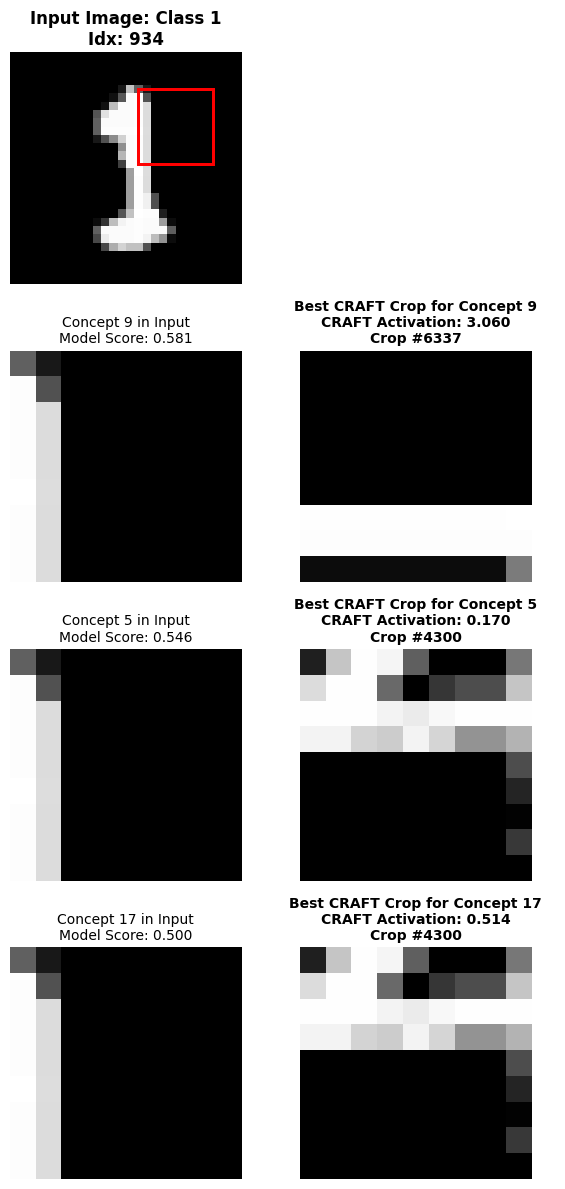

In [ ]:
def visualize_image_concepts_with_craft(model, dataset, crops, concept_activations,
                                        image_index=None, top_k=5, patch_size=12):
    """
    Visualizes a single image from dataset and the top K concepts that activate for it.
    Shows:
    - Left: Original input image with CAM heatmap
    - Right: Best CRAFT crops that represent each discovered concept

    Args:
        model: UCBM trained model
        dataset: Test dataset
        crops: CRAFT crops array [n_patches, H, W, C]
        concept_activations: Activation scores [n_patches, n_concepts]
        image_index: Index of image to visualize (random if None)
        top_k: Number of top concepts to display
        patch_size: Size of patches to show from input image
    """

    if image_index is None:
        image_index = np.random.randint(len(dataset))

    image, label = dataset[image_index]
    image_input = image.unsqueeze(0).to(model._device)  # Add batch dim

    # Get Model Internals
    model._backbone.eval()
    concepts = model._h.to(model._device)

    with torch.no_grad():
        # Get Spatial Features (Batch, Channels, H, W)
        feature_maps = model._backbone(image_input)

        # Get Global Concept Scores
        # Pool (B, C, H, W) -> (B, C)
        if len(feature_maps.shape) == 4:
            global_feats = torch.mean(feature_maps, dim=(2, 3))
        else:
            global_feats = feature_maps

        global_feats = global_feats.flatten(1)
        global_feats = global_feats / global_feats.norm(dim=1, keepdim=True)

        # Concept Scores: (1, Num_Concepts)
        concept_scores = torch.matmul(global_feats, concepts.T).squeeze()

        # Get Spatial Activation Maps for Top Concepts
        # Sort concepts by score
        top_scores, top_indices = torch.sort(concept_scores, descending=True)
        top_scores = top_scores[:top_k]
        top_indices = top_indices[:top_k]

        # Calculate CAMs only for these top concepts
        # Einsum: (1, Channels, H, W) x (K, Channels) -> (1, K, H, W)
        relevant_concepts = concepts[top_indices]
        cams = torch.einsum('bchw,kc->bkhw', feature_maps, relevant_concepts)

        # Upsample to image size
        cams_resized = F.interpolate(cams, size=image.shape[1:], mode='bilinear', align_corners=False)

    # Create figure: Original image + Top K concepts (2 columns: CAM + Best CRAFT crop)
    fig, axes = plt.subplots(top_k + 1, 2, figsize=(6, 3 * (top_k + 1)))

    if top_k == 1:
        axes = axes.reshape(1, -1)

    # ============================================
    # ROW 0: Original Input Image (spanning 2 columns)
    # ============================================
    ax_orig = axes[0, 0]
    img_disp = image.permute(1, 2, 0).numpy()
    if img_disp.shape[2] == 1:
        ax_orig.imshow(img_disp.squeeze(), cmap='gray')
    else:
        ax_orig.imshow(img_disp)
    ax_orig.set_title(f"Input Image: Class {label}\nIdx: {image_index}", fontsize=12, fontweight='bold')
    ax_orig.axis('off')

    # Hide the second column in first row
    axes[0, 1].axis('off')

    # ============================================
    # ROWS 1 to top_k: Concepts with CAM + Best CRAFT Crops
    # ============================================
    for k in range(top_k):
        c_idx = top_indices[k].item()
        score = top_scores[k].item()

        # -------- LEFT: CAM from input image --------
        ax_cam = axes[k + 1, 0]

        # Find Hotspot (Max activation in CAM)
        cam = cams_resized[0, k, :, :]
        idx_flat = torch.argmax(cam)
        h_idx, w_idx = idx_flat // image.shape[1], idx_flat % image.shape[2]

        # Crop Patch from input image
        h_start = max(0, h_idx.item() - patch_size // 2)
        w_start = max(0, w_idx.item() - patch_size // 2)
        h_end = min(image.shape[1], h_start + patch_size)
        w_end = min(image.shape[2], w_start + patch_size)

        patch_input = image[:, h_start:h_end, w_start:w_end]
        patch_disp = patch_input.permute(1, 2, 0).numpy()

        if patch_disp.shape[2] == 1:
            ax_cam.imshow(patch_disp.squeeze(), cmap='gray', vmin=0, vmax=1)
        else:
            ax_cam.imshow(patch_disp)

        ax_cam.set_title(f"Concept {c_idx} in Input\nModel Score: {score:.3f}", fontsize=10)
        ax_cam.axis('off')

        # Draw red rectangle showing where CAM looked
        rect = plt.Rectangle((w_start, h_start), w_end - w_start, h_end - h_start,
                             linewidth=2, edgecolor='red', facecolor='none')
        axes[0, 0].add_patch(rect)

        # -------- RIGHT: Best CRAFT crop for this concept --------
        ax_craft = axes[k + 1, 1]

        # Find the crop with highest activation for this concept
        concept_crop_activations = concept_activations[:, c_idx]
        best_crop_idx = np.argmax(concept_crop_activations)
        best_crop_activation = concept_crop_activations[best_crop_idx]

        # Get the crop
        best_crop = crops[best_crop_idx]

        # Display crop
        if best_crop.shape[2] == 1:
            ax_craft.imshow(best_crop.squeeze(), cmap='gray', vmin=0, vmax=1)
        else:
            ax_craft.imshow(best_crop)

        ax_craft.set_title(f"Best CRAFT Crop for Concept {c_idx}\nCRAFT Activation: {best_crop_activation:.3f}\nCrop #{best_crop_idx}",
                          fontsize=10, fontweight='bold')
        ax_craft.axis('off')

        # Add green border to highlight best crop
        for spine in ax_craft.spines.values():
            spine.set_edgecolor('green')
            spine.set_linewidth(2)
            spine.set_visible(True)

    plt.tight_layout()
    plt.show()


# Usage:
visualize_image_concepts_with_craft(ph_cbm, test_ds, crops, concept_activations, image_index=None, top_k=3, patch_size=9)

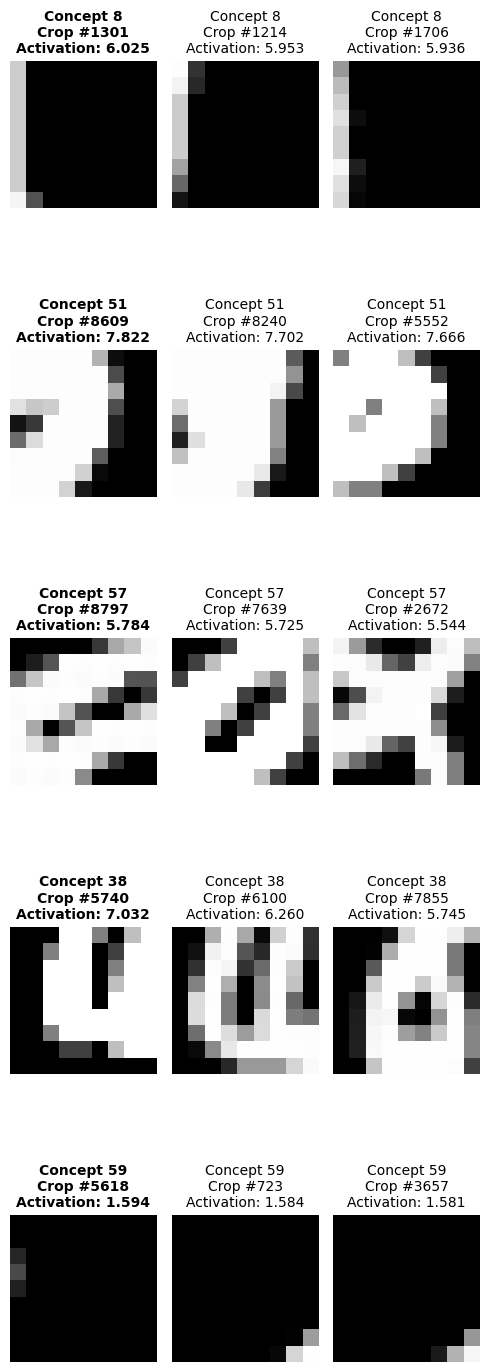

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_concepts_with_crops(crops, concept_activations, top_k=5):
    """
    Visualizes the top K concepts by showing the actual crops with the highest
    activation scores for each concept.

    Args:
        crops: Array of image patches [n_patches, H, W, C]
        concept_activations: Array of activation scores [n_patches, n_concepts]
        top_k: Number of top concepts to display
    """

    # Get average activation per concept across all patches
    concept_avg_activations = concept_activations.mean(axis=0)

    # Get top K concepts sorted by average activation
    top_concept_indices = np.argsort(concept_avg_activations)[-top_k:][::-1]

    fig, axes = plt.subplots(top_k, 3, figsize=(5, 3*top_k))

    if top_k == 1:
        axes = axes.reshape(1, -1)

    for k, concept_idx in enumerate(top_concept_indices):
        # Get activation scores for this concept
        concept_scores = concept_activations[:, concept_idx]

        # Find top 3 crops with highest activation
        top_3_indices = np.argsort(concept_scores)[-3:][::-1]
        top_3_scores = concept_scores[top_3_indices]

        # Display top 3 crops
        for col, (crop_idx, score) in enumerate(zip(top_3_indices, top_3_scores)):
            ax = axes[k, col]
            crop = crops[crop_idx]

            # Handle both grayscale and RGB
            if crop.shape[2] == 1:
                ax.imshow(crop.squeeze(), cmap='gray', vmin=0, vmax=1)
            else:
                ax.imshow(crop)

            ax.set_title(f"Concept {concept_idx}\nCrop #{crop_idx}\nActivation: {score:.3f}",
                        fontsize=10, fontweight='bold' if col == 0 else 'normal')
            ax.axis('off')

            # Add border to top crop
            if col == 0:
                for spine in ax.spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(3)
                    spine.set_visible(True)

    plt.tight_layout()
    plt.show()

# Usage:
visualize_concepts_with_crops(crops, concept_activations, top_k=5)

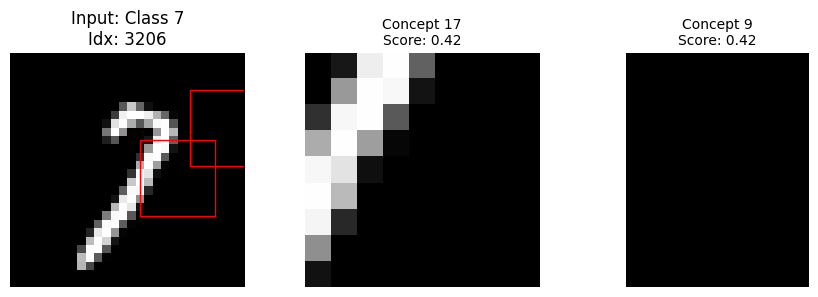

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np

def visualize_image_concepts(model, dataset, image_index=None, top_k=5, patch_size=12):
    """
    Visualizes a single image and the top K concepts that activate for it,
    showing the specific patch (crop) where each concept is looking.
    """
    if image_index is None:
        image_index = np.random.randint(len(dataset))

    image, label = dataset[image_index]
    image_input = image.unsqueeze(0).to(model._device) # Add batch dim

    # Get Model Internals
    model._backbone.eval()
    concepts = model._h.to(model._device)

    with torch.no_grad():
        # Get Spatial Features (Batch, Channels, H, W)
        feature_maps = model._backbone(image_input)

        # Get Global Concept Scores
        # Pool (B, C, H, W) -> (B, C)
        if len(feature_maps.shape) == 4:
            global_feats = torch.mean(feature_maps, dim=(2, 3))
        else:
            global_feats = feature_maps

        global_feats = global_feats.flatten(1)
        global_feats = global_feats / global_feats.norm(dim=1, keepdim=True)

        # Concept Scores: (1, Num_Concepts)
        concept_scores = torch.matmul(global_feats, concepts.T).squeeze()

        # Get Spatial Activation Maps for Top Concepts
        # Sort concepts by score
        top_scores, top_indices = torch.sort(concept_scores, descending=True)
        top_scores = top_scores[:top_k]
        top_indices = top_indices[:top_k]

        # Calculate CAMs only for these top concepts
        # Einsum: (1, Channels, H, W) x (K, Channels) -> (1, K, H, W)
        relevant_concepts = concepts[top_indices]
        cams = torch.einsum('bchw,kc->bkhw', feature_maps, relevant_concepts)

        # Upsample to image size
        cams_resized = F.interpolate(cams, size=image.shape[1:], mode='bilinear', align_corners=False)

    fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 3))

    # Plot Original Image
    ax_orig = axes[0]
    img_disp = image.permute(1, 2, 0).numpy()
    if img_disp.shape[2] == 1:
        ax_orig.imshow(img_disp.squeeze(), cmap='gray')
    else:
        ax_orig.imshow(img_disp)
    ax_orig.set_title(f"Input: Class {label}\nIdx: {image_index}", fontsize=12)
    ax_orig.axis('off')

    # Plot Top Concepts (Crops)
    for k in range(top_k):
        c_idx = top_indices[k].item()
        score = top_scores[k].item()

        # Find Hotspot (Max activation)
        cam = cams_resized[0, k, :, :]
        idx_flat = torch.argmax(cam)
        h_idx, w_idx = idx_flat // image.shape[1], idx_flat % image.shape[2]

        # Crop Patch
        h_start = max(0, h_idx.item() - patch_size // 2)
        w_start = max(0, w_idx.item() - patch_size // 2)
        h_end = min(image.shape[1], h_start + patch_size)
        w_end = min(image.shape[2], w_start + patch_size)

        patch = image[:, h_start:h_end, w_start:w_end]

        # Display Patch
        ax = axes[k + 1]
        patch_disp = patch.permute(1, 2, 0).numpy()

        if patch_disp.shape[2] == 1:
            ax.imshow(patch_disp.squeeze(), cmap='gray', vmin=0, vmax=1)
        else:
            ax.imshow(patch_disp)

        ax.set_title(f"Concept {c_idx}\nScore: {score:.2f}", fontsize=10)
        ax.axis('off')

        # Add a red box on the original image to show where it looked? (Optional)
        rect = plt.Rectangle((w_start, h_start), w_end-w_start, h_end-h_start,
                             linewidth=1, edgecolor='red', facecolor='none')
        ax_orig.add_patch(rect)

    plt.tight_layout()
    plt.show()

# Will pick a random image from Test set and show its top 5 concepts + patches
visualize_image_concepts(ph_cbm, test_ds, image_index=None, top_k=2, patch_size=9)

#### Pruebas de precision:

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import torch

# 1. Extraer los "Concept Embeddings" (X_train y X_test)
# Usamos el método interno de tu clase UCBM que llama a 'raw_concept_sims'
print("Extrayendo matriz de conceptos para Entrenamiento...")
X_train = ph_cbm._get_concept_embeddings(
    dataset=train_data,
    saved_activation_path=act_path,
    data_label="train",
#    normalize=normalize_concepts
).cpu().numpy()

print("Extrayendo matriz de conceptos para Prueba...")
X_test = ph_cbm._get_concept_embeddings(
    dataset=test_data,
    saved_activation_path=act_path,
    data_label="test",
#    normalize=normalize_concepts
).cpu().numpy()

# 2. Extraer las etiquetas correctas (Y_train y Y_test)
# Tu función 'load_data' (celda 19) ya inyectó el atributo '.targets' en los Subsets
Y_train = train_data.targets.cpu().numpy()
Y_test = test_data.targets.cpu().numpy()

# 3. La Prueba del Ácido: Evaluando la calidad de CRAFT
print(f"Dimensiones de la matriz X_train: {X_train.shape} (Debería ser [N_imágenes, {n_concepts}])")
print("Entrenando Regresión Logística pura (Sklearn)...")

# Configuramos un solver robusto
clf = LogisticRegression(max_iter=3000, C=1.0, solver='lbfgs')
clf.fit(X_train, Y_train)

train_acc = clf.score(X_train, Y_train)
test_acc = clf.score(X_test, Y_test)

print("-" * 50)
print(f"PRECISIÓN MÁXIMA POSIBLE DE TUS CONCEPTOS:")
print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy:  {test_acc*100:.2f}%")
print("-" * 50)

Extrayendo matriz de conceptos para Entrenamiento...


Extrayendo matriz de conceptos para Prueba...


Dimensiones de la matriz X_train: (56000, 20) (Debería ser [N_imágenes, 20])
Entrenando Regresión Logística pura (Sklearn)...
--------------------------------------------------
PRECISIÓN MÁXIMA POSIBLE DE TUS CONCEPTOS:
Train Accuracy: 92.99%
Test Accuracy:  92.79%
--------------------------------------------------


Tarea:
 -  Better patches
 - Identify a line, or a circle from an image, it's impossible because in the dataset of patches, there's no that kind of concepts, because the concepts learned are crops of the images, is not lines, circles, curved lines, etc. If we want our model identify that kind of concepts, we need to create the dataset to train the model to identify the concepts, what does craft with NMF is identify the proyection of the patch, call it "concept" based on the pixels activations.
 - intentar con crops_u, en lugar de W = reducer.components_

### Store in GOOGLE SHEETS

In [ ]:
import gspread
from google.colab import auth
from google.auth import default

def log_experiment_to_sheets(sheet_name, data_dict):
    # 1. Authenticate
    auth.authenticate_user()
    creds, _ = default()
    gc = gspread.authorize(creds)

    # 2. Open or Create the spreadsheet
    try:
        sh_file = gc.open(sheet_name)
        worksheet = sh_file.sheet1
    except gspread.exceptions.SpreadsheetNotFound:
        sh_file = gc.create(sheet_name)
        worksheet = sh_file.sheet1
        print(f"Created new spreadsheet: {sheet_name}")

    # 3. Improved check for existing data
    # Filter out empty rows to see if the sheet is truly "fresh"
    existing_data = [row for row in worksheet.get_all_values() if any(row)]

    headers = list(data_dict.keys())
    values = [str(v) for v in data_dict.values()]

    if not existing_data:
        # If empty: Add headers as the first row, then data as the second
        worksheet.append_rows([headers, values])

        # Optional: Bold the header row for better visibility
        worksheet.format("1:1", {"textFormat": {"bold": True}})
        print("Headers and first run added!")
    else:
        # If headers exist, ensure data matches the order of the header keys
        # This prevents data mismatch if you change the dict order later
        current_headers = existing_data[0]
        ordered_values = [str(data_dict.get(h, "")) for h in current_headers]
        worksheet.append_row(ordered_values)
        print("Experiment results appended successfully!")

# --- USAGE ---
"""
# Your data from the model training
info_dict = {
  "amount of concepts": 5,
  "amount of classes": 10,
  "amount of samples": 1000,
  "samples per class": 100.0,
  "total patches": 25000,
  "patch_size": 7,
  "train acc": 0.09987500309944153,
  "test acc": 0.10000000149011612,
  "train auroc": 0.8547834157943726,
  "test auroc": 0.8564850091934204,
  "avg non zero concept ratio": 1.0,
  "learning rate": 0.01,
  "lambda gate": 0.0,
  "lambda w": 0.0,
  "dropout p": 0.0,
  "scale mode": "no",
  "bias mode": "no",
  "multilabel": False,
  "k": -1
}"""

# Log it!
log_experiment_to_sheets("My_CBM_Experiments_1", info_dict)

Experiment results appended successfully!


In [ ]:
from google.colab import auth
import gspread
from google.auth import compute_engine
import pandas as pd

# 1. Authenticate (Only once per session)
auth.authenticate_user()
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Open your sheet (Create a sheet named "Model_Experiments" first)
sh = gc.open("Model_Experiments").sheet1

# 3. Append your dictionary
# Convert dict values to a list in the same order as your columns
row_to_append = list(info_dict.values())
sh.append_row(row_to_append)

print("Experiment data synced to Google Sheets!")

SpreadsheetNotFound: <Response [200]>

### Store in weigths and biases

In [ ]:
!pip install wandb -qU

In [ ]:
import wandb
from datetime import datetime

def log_experiment_to_wandb(project_name, run_name, data_dict):
    """
    Logs experiment results to Weights & Biases.
    """
    # 1. Login (This will prompt you for an API key the first time)
    # Get your key at: https://wandb.ai/authorize
    wandb.login()

    # 2. Initialize a new run
    # 'config' stores hyperparameters, 'name' helps you identify this specific test
    run = wandb.init(
        project=project_name,
        name=run_name,
        config=data_dict
    )

    # 3. Log the metrics
    # W&B treats 'config' as the setup and 'log' as the results.
    # Since your info_dict has both, we log everything.
    wandb.log(data_dict)

    # 4. Finish the run
    wandb.finish()
    print(f"✅ Experiment '{run_name}' synced to W&B Dashboard!")

# --- USAGE ---

# Generate a unique name for this run using the current time
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
run_id = f"CBM_Exp_{current_time}"

# Use your existing info_dict
info_dict = {
  "amount of concepts": 5,
  "amount of classes": 10,
  "amount of samples": 1000,
  "train acc": 0.0998,
  "test acc": 0.1000,
  "learning rate": 0.01,
  "lambda gate": 0.0,
}

# Log it!
log_experiment_to_wandb("my-cbm-project", run_id, info_dict)